# LSST SN Ia Simulation Pipeline

Forward-model SN Ia light curves with the lsstcam Science Validation cadence using `lightcurvelynx`.

**Survey**: lsstcam Science Validation visits (`lsstcam_20250930.db`)  
**Model**: SALT3 via `SncosmoWrapperModel`  
**Filters**: u, g, r, i, z, y  
**Redshift**: volumetric rate (Frohmaier et al. 2019), z = 0.01–1.2  
**Parameters**: Gaussian priors for x1 and c (no pzflow, no host galaxy)

## 1. Imports

## 0. Environment Setup

Set `LIGHTCURVELYNX_DATA_DIR` **before** importing lightcurvelynx — the download path is resolved at import time.  
Downloaded files (OpSim DB, passbands) will be stored in `./data/` inside this project directory.

In [1]:
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path

# Store downloaded data inside this project so it travels with the repo checkout.
# Must be set before any lightcurvelynx imports (path is resolved at import time).
_data_dir = Path().resolve() / "data"
_data_dir.mkdir(exist_ok=True)
os.environ["LIGHTCURVELYNX_DATA_DIR"] = str(_data_dir)
print(f"LIGHTCURVELYNX_DATA_DIR = {_data_dir}")

LIGHTCURVELYNX_DATA_DIR = /Users/mi/Work/lightcurvelynx_rubin_dp2/data


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from nested_pandas import read_parquet
from joblib import Parallel, delayed
import sncosmo

from lightcurvelynx.obstable.lsst_obstable import LSSTObsTable
from lightcurvelynx.utils.io_utils import read_sqlite_table
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    snia_volumetric_rates,
)
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler,ApproximateMOCSampler
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect

## 2. Simulation Configuration

In [4]:
SEED = 1024
RNG  = np.random.default_rng(SEED)

SIM_PARAMS = {
    # Cosmology
    "H0": 73.0,
    "Omega_m": 0.3,
    # Redshift range
    "zmin": 0.01,
    "zmax": 1.2,
    "znbins": 100,
    # Tripp relation coefficients
    "alpha": 0.14,
    "beta": 3.1,
    # SALT3 Gaussian priors (no pzflow, no host galaxy)
    "x1_mean": 0.0,  "x1_sigma": 1.0,
    "c_mean":  0.0,  "c_sigma":  0.1,
    "m_abs_mean": -19.3, "m_abs_sigma": 0.12,
    # Survey
    "filters": ["u", "g", "r", "i", "z", "y"],
    "sky_coverage": 18_000.0,  # LSST WFD footprint in deg²
}

## 3. Load LSST Visit Table

In [5]:
_sv_table = read_sqlite_table(
    "data/visittable/lsstcam_20250930.db",
    sql_query="SELECT * FROM observations",
)
_sv_table_wfd = _sv_table[~_sv_table['observation_reason'].str.contains('ddf')]

obstable = LSSTObsTable.from_sv_visits_table(_sv_table_wfd)
print(f"Visit table loaded: {len(obstable):,} observations")
print(f"MJD range: {obstable['time'].min():.1f} – {obstable['time'].max():.1f}")
print(f"Filters:    {sorted(obstable['filter'].unique())}")

Visit table loaded: 19,602 observations
MJD range: 60790.2 – 60940.1
Filters:    ['g', 'i', 'r', 'u', 'y', 'z']


In [6]:
sky_coverage = obstable.estimate_coverage()    
# sky_coverage = 75
SIM_PARAMS["sky_coverage"] = sky_coverage
print(f"Estimated sky coverage: {sky_coverage:.0f} deg²")

Estimated sky coverage: 4922 deg²


## 4. Calculate Number of SNe to Simulate

Integrate the volumetric SN Ia rate over the survey volume and duration:
$$N = \int_{z_{\rm min}}^{z_{\rm max}} r_v(z)\,\frac{dV}{dz}\,\frac{dz}{1+z} \times \Omega \times T_{\rm survey}$$

In [7]:
t_min = float(obstable["time"].min())
t_max = float(obstable["time"].max())

survey_length = (t_max - t_min) / 365.25
print(f"Survey length = {survey_length:.2f} years")

solid_angle = SIM_PARAMS["sky_coverage"] * (np.pi / 180.0) ** 2
print(f"Solid angle   = {solid_angle:.4f} sr  ({SIM_PARAMS['sky_coverage']:,.0f} deg²)")

nsntotal, _ = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    znbins=1,
    solid_angle=solid_angle,
    vol_rate_function=snia_volumetric_rates,
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
nsn = int(nsntotal[0] * survey_length)
# nsn = 100
print(f"Expected SNe Ia = {nsn:,}")

Survey length = 0.41 years
Solid angle   = 1.4992 sr  (4,922 deg²)
Expected SNe Ia = 378,602


## 5. Load LSST Passbands

In [8]:
passbands = PassbandGroup.from_preset("LSST", filters=SIM_PARAMS["filters"])
print(passbands)

PassbandGroup containing 6 passbands: LSST_u, LSST_g, LSST_r, LSST_i, LSST_z, LSST_y


## 6. Redshift Distribution (Volumetric Rate)

Use the Frohmaier et al. (2019) volumetric rate $r_v(z) = r_0\,(1+z)^\alpha$ to compute the
expected number of SNe Ia per redshift bin, then build an interpolated PDF for sampling.

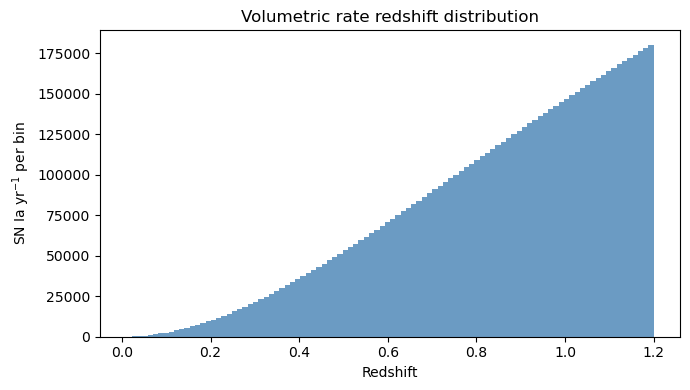

In [9]:
nsn_per_bin, z_mean = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    SIM_PARAMS["znbins"],
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
zpdf = interp1d(z_mean, nsn_per_bin, bounds_error=False, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
dz = (SIM_PARAMS["zmax"] - SIM_PARAMS["zmin"]) / SIM_PARAMS["znbins"]
ax.bar(z_mean, nsn_per_bin, width=dz, color="steelblue", alpha=0.8)
ax.set(xlabel="Redshift", ylabel="SN Ia yr$^{-1}$ per bin",
       title="Volumetric rate redshift distribution")
plt.tight_layout()
plt.show()

## 7. Build SN Ia Source Model

Parameter graph:
- **RA, Dec** — uniformly sampled from the observed LSST footprint (`ObsTableUniformRADECSampler`)
- **redshift** — drawn from the volumetric rate PDF (`SamplePDF`)
- **x1** — Gaussian($\mu=0$, $\sigma=1$)
- **c** — Gaussian($\mu=0$, $\sigma=0.1$)
- **M_abs** — Gaussian($\mu=-19.3$, $\sigma=0.12$)
- **distmod** — computed from redshift via `DistModFromRedshift`
- **x0** — computed via the Tripp relation through `X0FromDistMod`

In [10]:
# RA/Dec: uniform over the obstable footprint (rejection sampling)
# radec = ObsTableUniformRADECSampler(obstable, node_label="radec")
moc = obstable.build_moc(max_depth=12)
radec = ApproximateMOCSampler(moc, node_label="radec")

# Redshift from volumetric rate PDF
z_func = SamplePDF(zpdf, node_label="redshift")

# Gaussian SALT3 parameter priors
x1_func    = NumpyRandomFunc("normal", loc=SIM_PARAMS["x1_mean"],    scale=SIM_PARAMS["x1_sigma"])
c_func     = NumpyRandomFunc("normal", loc=SIM_PARAMS["c_mean"],     scale=SIM_PARAMS["c_sigma"])
m_abs_func = NumpyRandomFunc("normal", loc=SIM_PARAMS["m_abs_mean"], scale=SIM_PARAMS["m_abs_sigma"])

# x0 via Tripp relation
distmod_func = DistModFromRedshift(
    z_func, H0=SIM_PARAMS["H0"], Omega_m=SIM_PARAMS["Omega_m"]
)
x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=x1_func,
    c=c_func,
    alpha=SIM_PARAMS["alpha"],
    beta=SIM_PARAMS["beta"],
    m_abs=m_abs_func,
    node_label="x0_func",
)

# Extrapolation settings
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecayOnMag(decay_rate=0.02, mag_thres=30.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()

# Assemble the SALT3 source (no host galaxy)
source = SncosmoWrapperModel(
    "salt3",
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=x1_func,
    c=c_func,
    ra=radec.ra,
    dec=radec.dec,
    redshift=z_func,
    node_label="source",
    time_extrapolation=(time_extrap_before,time_extrap_after),
    wave_extrapolation=(wave_extrap_before,wave_extrap_after),  
)

mwextinction = SFDMap(
    ra=source.ra,
    dec=source.dec,
    node_label="mwext",
)
# Create an extinction effect using the EBVs from that dust map.
ext_effect = ExtinctionEffect(extinction_model="F99", ebv=mwextinction, 
                              r_v=3.1,frame='observer',backend="dust_extinction")
source.add_effect(ext_effect)

print("Source model built successfully.")

Source model built successfully.


## 8. Run Simulation

In [11]:
obstable.columns

Index(['observationId', 'exposure_name', 'controller', 'day_obs', 'seq_num',
       'physical_filter', 'filter', 'ra', 'dec', 'rotation',
       ...
       'slew_model', 'slew_model_ideal', 'model_gap', 'slewDistance',
       'overhead', 'fault', 'jd', 'nexp', 'night', 'zp'],
      dtype='object', length=218)

In [12]:
param_cols = [
    "source.t0",
    "source.x0",
    "source.x1",
    "source.c",
    "source.redshift",
    "source.ra",
    "source.dec",
    "x0_func.distmod",
]
obstable_save_cols = ["zp"]

lightcurves = simulate_lightcurves(
    model=source,
    num_samples=nsn,
    obstable=obstable,
    passbands=passbands,
    param_cols=param_cols,
    obstable_save_cols=obstable_save_cols,
    rng=RNG,
    num_jobs=6,
    batch_size=3000,
)
print(f"Simulated {len(lightcurves):,} SNe Ia")
lightcurves.head()

Simulating: 100%|██████████| 3000/3000 [00:13<00:00, 223.19obj/s]


Simulated 378,602 SNe Ia


id          ra        dec  nobs            t0         z  \
0   0  240.532628 -11.449563    45  60813.102295  0.555660   
1   1  330.644702 -47.944585     1  60889.440243  0.884975   
2   2  318.014869  -6.087551    32  60794.824301  1.072021   
3   3  295.059092 -25.836671    58  60914.063804  1.181548   
4   4  268.604166 -18.586412    42  60806.869954  0.526269   

                                              params     source_t0  source_x0  \
0  {'radec.ra': 240.53262764588, 'radec.dec': -11...  60813.102295   0.000008   
1  {'radec.ra': 330.64470248092493, 'radec.dec': ...  60889.440243   0.000004   
2  {'radec.ra': 318.0148693174124, 'radec.dec': -...  60794.824301   0.000002   
3  {'radec.ra': 295.05909176543355, 'radec.dec': ...  60914.063804   0.000002   
4  {'radec.ra': 268.6041662748903, 'radec.dec': -...  60806.869954   0.000014   

   source_x1  source_c  source_redshift   source_ra  source_dec  \
0   0.135318  0.028433         0.555660  240.532628  -11.449563   
1  -1.477202 -0.122148         0.884975  330.644702  -47.944585   
2  -2.453308 -0.059777         1.072021  318.014869   -6.087551   
3  -0.962336 -0.044964         1.181548  295.059092  -25.836671   
4   0.423437 -0.112629         0.526269  268.604166  -18.586412   

   x0_func_distmod                                         lightcurve  
0        42.446004  [{mjd: 60847.150434, filter: 'i', flux: 369.55...  
1        43.681426  [{mjd: 60925.336688, filter: 'i', flux: -1853....  
2        44.195881  [{mjd: 60847.253322, filter: 'i', flux: 159.21...  
3        44.457269  [{mjd: 60847.371026, filter: 'i', flux: -161.3...  
4        42.303691  [{mjd: 60847.356211, filter: 'z', flux: -177.2...

## 9. Save Results

In [ ]:
# # save results
# output_path = "outputs/lsst_snia_results.parquet"
# output_path = Path(output_path)
# output_path.parent.mkdir(exist_ok=True)
# lightcurves.to_parquet(output_path)
# print(f"Saved to {output_path}")

In [ ]:
# lightcurves = read_parquet("outputs/lsst_snia_results.parquet")

## 10. Apply Selections

In [15]:
# calculate detection flag
lightcurves = lightcurves.dropna(subset=['lightcurve'])

print("Before applying detection: nsn=", len(lightcurves))
lightcurves['lightcurve.snr'] = lightcurves['lightcurve.flux']/lightcurves['lightcurve.fluxerr']
detection_snr_thres = 5.
lightcurves['lightcurve.detection_flag'] = lightcurves['lightcurve.snr'] > detection_snr_thres

# drop saturation
lightcurves_after_drop_sat = lightcurves.query("lightcurve.is_saturated==False").dropna(subset=['lightcurve'])
print("After droppoing saturation: nsn=", len(lightcurves_after_drop_sat))

lightcurves_after_detection = lightcurves_after_drop_sat.query("lightcurve.detection_flag == True").dropna(subset=['lightcurve'])
print("After applying detection: nsn=", len(lightcurves_after_detection))

Before applying detection: nsn= 377819


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1352: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


After droppoing saturation: nsn= 377819


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1352: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


After applying detection: nsn= 64808


In [30]:
# define quality cuts for lightcurves
def lc_quality_cuts(flux,mjd,filter,z,t0,n_phases=7, n_before_peak=2, n_after_peak=3, n_bands=2):
    phases = np.floor((mjd - t0)/(1. + z))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases<=40)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    if np.sum(good_idx) == 0:
        return {"pass_quality_cuts": False}
    pass_before = np.sum(unique_phases[good_idx] < 0) >= n_before_peak
    pass_after = np.sum(unique_phases[good_idx] > 0) >= n_after_peak
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    pass_cut &= pass_before
    pass_cut &= pass_after
    pass_cut &= len(np.unique(filter[unique_idx][good_idx])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

In [31]:
pass_quality_cut = lightcurves_after_detection.reduce(lc_quality_cuts,"lightcurve.flux",
                                                           "lightcurve.mjd","lightcurve.filter","z","t0")
idx = pass_quality_cut.query("pass_quality_cuts == True").index
lightcurves_after_quality_cut = lightcurves_after_detection.loc[idx]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

lightcurves["pass_quality_cuts"] = False
lightcurves.loc[idx,"pass_quality_cuts"] = True

/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_83057/1109435972.py:1: DeprecationWarning: Call to deprecated method reduce. (`reduce` will be removed in version 0.7.0, use `map_rows` instead.) -- Deprecated since version 0.6.0.
  pass_quality_cut = lightcurves_after_detection.reduce(lc_quality_cuts,"lightcurve.flux",


After quality cuts: nsn= 4663


## 11. Diagnostics

Quick sanity checks on the simulated population.

In [32]:
results = lightcurves_after_quality_cut

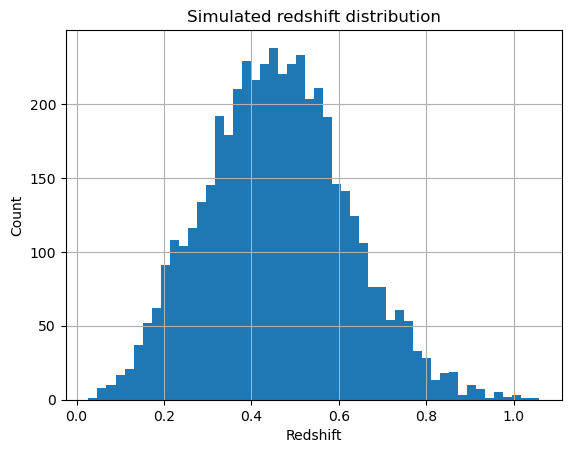

In [33]:
# redshift distribution of simulated SNe
fig, ax = plt.subplots()
results["source_redshift"].hist(bins=50, ax=ax)
ax.set(xlabel="Redshift", ylabel="Count", title="Simulated redshift distribution")
plt.show()

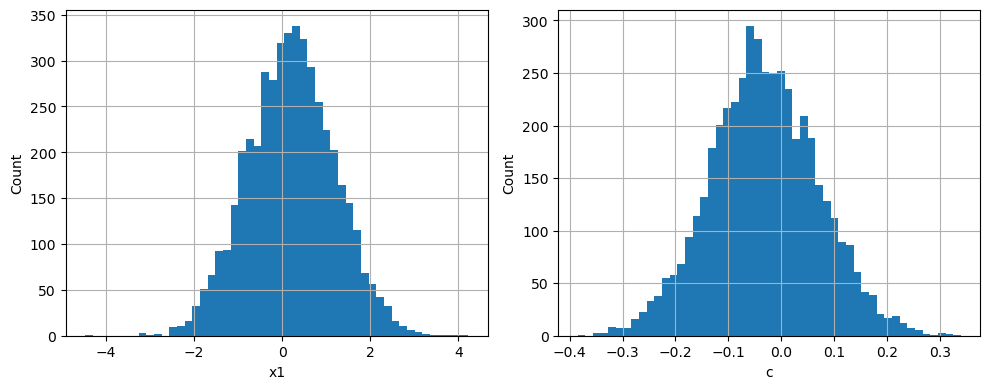

In [34]:
# x1 and c distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
results["source_x1"].hist(bins=50, ax=axes[0])
axes[0].set(xlabel="x1", ylabel="Count")
results["source_c"].hist(bins=50, ax=axes[1])
axes[1].set(xlabel="c", ylabel="Count")
plt.tight_layout()
plt.show()

             mjd filter         flux     fluxerr  flux_perfect  survey_idx  \
0   60869.297605      i  3616.741338  535.507000   2765.755115           0   
1   60874.279762      r  6232.206003  284.873012   6503.364361           0   
2   60875.287721      r  7451.180608  185.664716   7434.537267           0   
3   60876.262480      g  6845.603361  138.517734   6975.705828           0   
4   60877.307100      i  8132.339363  538.075085   8768.955671           0   
5   60878.288908      g  8524.525506  111.572801   8578.565839           0   
6   60879.279984      u  2306.720363  378.578426   2282.134016           0   
7   60880.276403      g  9137.252889  354.117392   9356.614033           0   
8   60904.173822      i  7001.402161  335.059035   6633.394729           0   
9   60904.222839      r  5393.119358  204.994686   5446.640974           0   
10  60904.250756      r  5629.904792  222.202573   5435.990376           0   
11  60904.263396      i  6853.702701  256.870321   6615.176479  

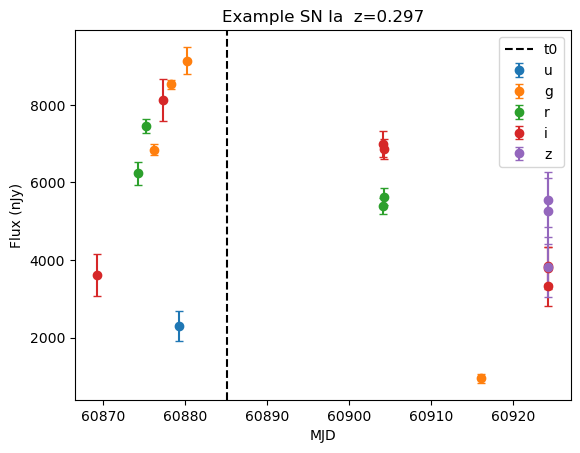

In [40]:
# example light curve for a single SN
sn = results.iloc[np.random.choice(len(results))]
lc = sn["lightcurve"]
print(lc)
for band in SIM_PARAMS["filters"]:
    mask = lc["filter"] == band
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) > -20  # only show points within 20 days before t0
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) < 100   # only show points within 20 days after t0
    if mask.any():
        plt.errorbar(lc["mjd"][mask], lc["flux"][mask], lc["fluxerr"][mask],
                     fmt="o", label=band, capsize=3)
plt.axvline(sn["source_t0"], ls="--", color="k", label="t0")
plt.legend()
plt.xlabel("MJD")
plt.ylabel("Flux (nJy)")
plt.title(f'Example SN Ia  z={sn["source_redshift"]:.3f}')
plt.show()

In [41]:
# append system path 

from utils.lcfit import fit_single_lc  

def fit_single_lc_w_cond(lc,
                         bounds={"x1": (-4,4),
                                 "c": (-0.4,0.4),},
                         phase_range=(-10,40),
                         modelcov=False):
    return fit_single_lc(lc,mpbounds=bounds,phase_range=phase_range,modelcov=modelcov)

In [42]:
res = fit_single_lc_w_cond(lightcurves_after_quality_cut.iloc[0])
res

success        1.0
ncall        138.0
             ...  
id            64.0
fit_error      NaN
Length: 54, dtype: float64

In [43]:
lc_to_fit = lightcurves_after_quality_cut.iloc[0:]

In [26]:
%%time
results = Parallel(n_jobs=10)(delayed(fit_single_lc_w_cond)(row) for _index, row in lc_to_fit.iterrows())
result_df = pd.DataFrame(results)

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


CPU times: user 2.6 s, sys: 810 ms, total: 3.41 s
Wall time: 1min 2s


In [27]:
saltparcuts = (result_df.x1 > -3) & (result_df.x1 < 3)
saltparcuts &= (result_df.c > -0.3) & (result_df.c < 0.3)
saltparcuts &= (result_df.success == True)

<Axes: >

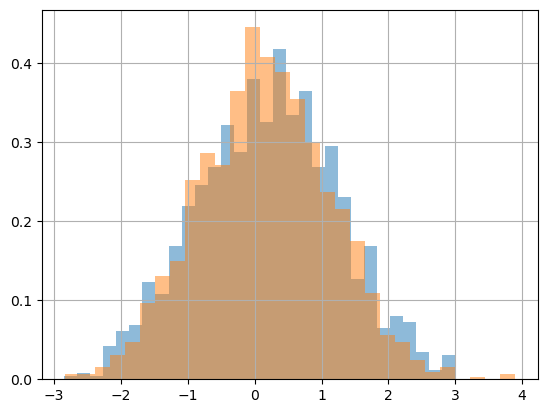

In [28]:
result_df[saltparcuts].x1.hist(bins=30,alpha=0.5,density=True)
lightcurves_after_quality_cut.source_x1.hist(bins=30,alpha=0.5,density=True)

<Axes: >

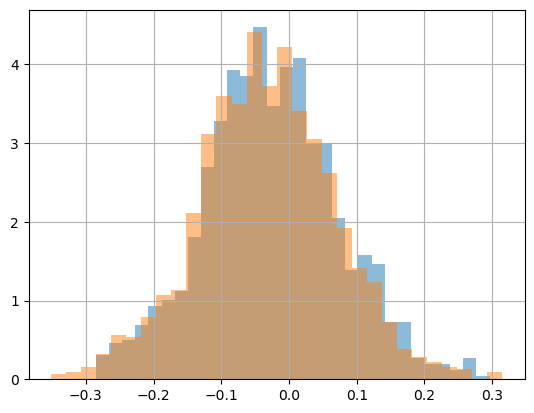

In [29]:
result_df[saltparcuts].c.hist(bins=30,alpha=0.5,density=True)
lightcurves_after_quality_cut.source_c.hist(bins=30,alpha=0.5,density=True)